In [1]:
import tensorflow as tf
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
model = tf.keras.models.load_model(
    "../models/efficientnet_brain_tumor.keras"
)

In [3]:
TEST_DIR = "../datasets/classification/Testing"

IMG_SIZE = (224,224)

BATCH_SIZE = 16

In [4]:
test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False
)

Found 1600 files belonging to 4 classes.


In [5]:
class_names = test_ds.class_names

print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
y_true = np.concatenate(
    [y for x,y in test_ds],
    axis=0
)

In [7]:
predictions = model.predict(
    test_ds
)

y_pred = np.argmax(
    predictions,
    axis=1
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 351ms/step


In [8]:
test_loss, test_accuracy = model.evaluate(
    test_ds
)

print("Test Accuracy:", test_accuracy)

100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 331ms/step - accuracy: 0.8350 - loss: 0.4946
Test Accuracy: 0.8349999785423279


In [9]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.88      0.66      0.75       400
  meningioma       0.79      0.71      0.75       400
     notumor       0.87      0.98      0.92       400
   pituitary       0.81      0.99      0.89       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.83      1600
weighted avg       0.84      0.83      0.83      1600



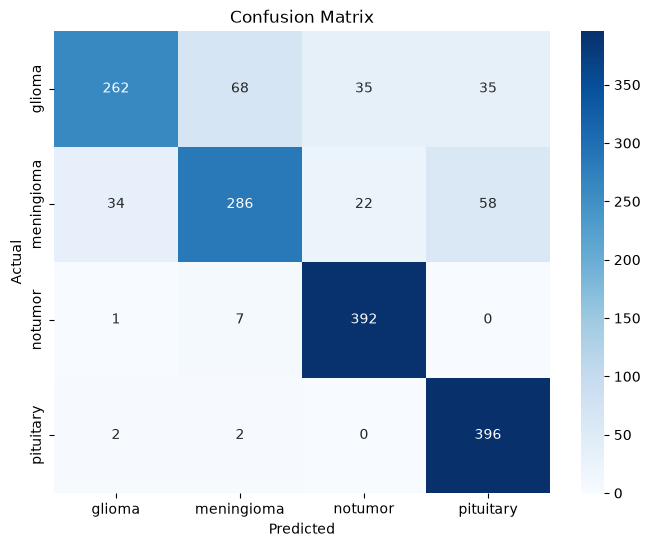

In [10]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [11]:
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8349999785423279
